In [1]:
# !pip install pmdarima


In [2]:
# pip install --upgrade numpy scipy Cython pmdarima --force-reinstall --no-cache-dir


In [3]:
from pmdarima import auto_arima

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('AirPassengers.csv',parse_dates=['Month'],index_col='Month')

In [11]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
# Fit auto_arima function to AirPassengers dataset

In [12]:
stepwise_fit=auto_arima(df['#Passengers'],start_p=1,start_q=1,
                       max_p=3,max_q=3,
                        m=12,                    # Seasonal period: 12 = monthly data with yearly seasonality.
                       start_P=0,                # Starting value for seasonal AR order (P) to begin search.
                       seasonal=True,            # Indicates you want to use a seasonal ARIMA model (SARIMA)
                       d=None,                   # Let auto_arima determine the order of non-seasonal differencing using statistical tests.
                       D=1,                      # Number of seasonal differences to apply (usually 1 for seasonal data).
                       trace=True,               # Prints out all the models tested and their AIC scores (for transparency).
                       error_action='ignore',    # We dont wanna know if an order does not work
                       suppress_warnings=True,   # We dont want convergence Warning
                       stepwise=True)            # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.28 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.18 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.29 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.75 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.32 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.19 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.37 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.49 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.29 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.11 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.63 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [13]:
stepwise_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Fri, 20 Jun 2025   AIC                           1019.178
Time:                                     15:36:23   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
train=df.iloc[:len(df)-12]
test=df.iloc[len(df)-12:]   # set one year for testing

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [21]:
model=SARIMAX(train['#Passengers'],
              order=(0,1,1),
              seasonal_order=(2,1,0,12))
result=model.fit()
result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                         #Passengers   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -446.830
Date:                             Fri, 20 Jun 2025   AIC                            901.659
Time:                                     15:49:24   BIC                            912.776
Sample:                                 01-01-1949   HQIC                           906.173
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2556      0.080     -3.190      0.001      -0.413      -0.099
ar.S.L12      -0.0962      0.090     -1.073      0.283      -0.272       0.080
ar.S.L24       0.1454      0.101      1.445      0.149      -0.052       0.343
sigma2       106.2408     15.243      6.970      0.000      76.364     136.117
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.01
Prob(Q):                              0.86   Prob(JB):                         0.99
Heteroskedasticity (H):               1.63   Skew:                             0.01
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Month'>

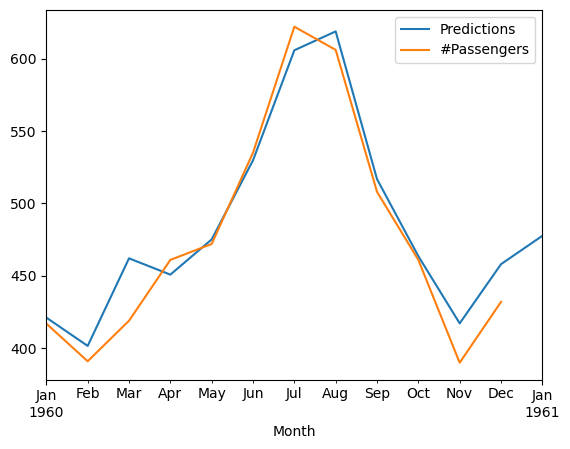

In [23]:
start=len(train)
end=len(train)+len(test)

prediction=result.predict(start=start,end=end,typ='levels',dynamic=False).rename('Predictions')  
#'levels' means return predictions in the original scale (undoing differencing).
#'linear' (older versions) or 'residual' would return transformed data (e.g., differenced values).
# .rename('Predictions'), this renames the returned Series to "Predictions" for clarity, which helps especially when plotting or comparing with actuals.

prediction.plot(legend=True)
test['#Passengers'].plot(legend=True)

In [24]:
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

In [28]:
prediction = prediction[:len(test)]

rmse(test['#Passengers'],prediction)

np.float64(18.38077771636337)

In [29]:
mean_squared_error(test['#Passengers'],prediction)

337.8529894583601

In [33]:
model=SARIMAX(df['#Passengers'],
             order=(0,1,1),
             seasonal_order=(2,1,0,12))
result=model.fit()
# model.summary()

In [34]:
forecast=result.predict(start=len(df),end=len(df)+12*3,
                       typ='levels').rename('Forecast')

<Axes: xlabel='Month'>

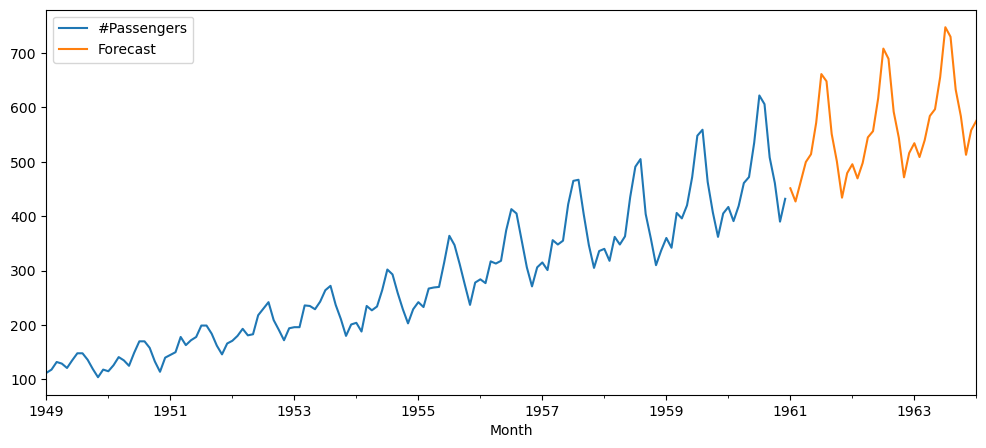

In [35]:
df['#Passengers'].plot(figsize=(12,5),legend=True)
forecast.plot(legend=True)